In [13]:


from pathlib import Path
import pydicom

# Point this to your .IMA path
file_path = Path("../Data/Organized_DICOM_4DFlow/Anonymous/Unknown/001_20240313_3T_1.MR.0017.0001.2024.03.26.12.11.25.918220.61293773.IMA")

# stop_before_pixels=True skips pixel data for speed; set to False if you also want pixel-related tags
ds = pydicom.dcmread(file_path, stop_before_pixels=True)

for elem in ds.iterall():  # iterall walks the full dataset, including sequences
    # elem.tag is a pydicom Tag; elem.name is the keyword/name; elem.value is the stored value
    print(f"{elem.tag} | {elem.name} | {elem.value}")

(0008, 0005) | Specific Character Set | ISO_IR 100
(0008, 0008) | Image Type | ['DERIVED', 'PRIMARY', 'MSUM', 'RETRO', 'NORM', 'DIS2D']
(0008, 0012) | Instance Creation Date | 20240313
(0008, 0013) | Instance Creation Time | 115538.423000
(0008, 0016) | SOP Class UID | 1.2.840.10008.5.1.4.1.1.4
(0008, 0018) | SOP Instance UID | 1.3.12.2.1107.5.2.43.166117.30000024032611113273900004003
(0008, 0020) | Study Date | 20240313
(0008, 0021) | Series Date | 20240313
(0008, 0022) | Acquisition Date | 20240313
(0008, 0023) | Content Date | 20240313
(0008, 0030) | Study Time | 111005.778000
(0008, 0031) | Series Time | 115538.422000
(0008, 0032) | Acquisition Time | 112528.565000
(0008, 0033) | Content Time | 115538.423000
(0008, 0050) | Accession Number | 
(0008, 0060) | Modality | MR
(0008, 0070) | Manufacturer | SIEMENS
(0008, 0090) | Referring Physician's Name | 
(0008, 1090) | Manufacturer's Model Name | Prisma
(0008, 1140) | Referenced Image Sequence | [(0008, 1150) Referenced SOP Class UID

In [4]:
import os
import shutil
import pydicom
import re

def limpiar_nombre(texto):
    """Elimina caracteres extraños para usar como nombre de carpeta"""
    return re.sub(r'[^a-zA-Z0-9_-]', '_', str(texto))

def clasificar_archivo_v4(file_path):
    """
    Retorna una tupla (Categoria_Principal, Nombre_Especifico_Serie)
    """
    try:
        ds = pydicom.dcmread(file_path, stop_before_pixels=True)
        
        # 1. Obtener datos descriptivos
        p_name = str(ds.get("ProtocolName", "NoProto")).strip()
        s_desc = str(ds.get("SeriesDescription", "NoSeries")).strip()
        seq_name = str(ds.get("SequenceName", "")).strip()
        
        # Usar ProtocolName preferiblemente, o SeriesDescription si falla
        # Si el nombre es muy genérico, agregamos SequenceName para diferenciar
        nombre_serie = p_name if len(p_name) > 3 else s_desc
        if seq_name:
            nombre_serie += f"_{seq_name}"
            
        nombre_serie = limpiar_nombre(nombre_serie)
        
        # Combinar texto para detección de dirección
        full_header_info = f"{p_name} {s_desc} {seq_name}".lower()
        
        # 2. Clasificación Tipo
        image_type = ds.get("ImageType", [])
        image_type_str = [x.upper() for x in image_type]

        categoria = "Unknown"

        # Detección
        if 'MSUM' in image_type_str:
            categoria = "Magnitude_MSUM"
        elif any(x in image_type_str for x in ['M', 'MAGNITUDE']):
            categoria = "Magnitude"
        elif any(x in image_type_str for x in ['P', 'PHASE', 'V', 'VELOCITY']):
            if any(x in full_header_info for x in ['rl', 'right', 'flow_x', 'in_plane']):
                categoria = "Phase_Vx"
            elif any(x in full_header_info for x in ['ap', 'anterior', 'flow_y']):
                categoria = "Phase_Vy"
            elif any(x in full_header_info for x in ['in', 'fh', 'foot', 'head', 'flow_z']):
                categoria = "Phase_Vz"
            else:
                categoria = "Phase_Other"
        else:
            # Fallback para casos raros (ej. derivadas sin tag P/M claro)
            if "pc3d" in full_header_info or "flow" in full_header_info:
                if "rl" in full_header_info: categoria = "Phase_Vx"
                elif "ap" in full_header_info: categoria = "Phase_Vy"
                elif "in" in full_header_info: categoria = "Phase_Vz"
                else: categoria = "Magnitude"
        
        return categoria, nombre_serie

    except Exception:
        return None, None

def procesar_pacientes_final(root_input_dir, root_output_dir):
    print(f"--- Iniciando Organización Detallada ---")
    print(f"Origen: {root_input_dir}")
    print(f"Destino: {root_output_dir}\n")

    pacientes = [d for d in os.listdir(root_input_dir) 
                 if os.path.isdir(os.path.join(root_input_dir, d)) 
                 and d != os.path.basename(root_output_dir)]
    
    for i, paciente in enumerate(pacientes):
        path_paciente = os.path.join(root_input_dir, paciente)
        print(f"[{i+1}/{len(pacientes)}] Paciente: {paciente}")
        
        conteo_carpetas = {}

        for root, dirs, files in os.walk(path_paciente):
            for filename in files:
                if filename.upper().endswith((".IMA", ".DCM")):
                    file_path = os.path.join(root, filename)
                    
                    categoria, nombre_serie = clasificar_archivo_v4(file_path)
                    
                    if categoria:
                        # NOMBRE DE CARPETA FINAL: Categoria + NombreSerie
                        # Ej: Magnitude_fl3d1r_t70
                        folder_name = f"{categoria}_{nombre_serie}"
                        
                        dest_path = os.path.join(root_output_dir, paciente, folder_name)
                        if not os.path.exists(dest_path):
                            os.makedirs(dest_path)
                        
                        shutil.copy2(file_path, os.path.join(dest_path, filename))
                        
                        # Contar para el reporte
                        conteo_carpetas[folder_name] = conteo_carpetas.get(folder_name, 0) + 1

        # Imprimir resumen de qué carpetas se crearon para este paciente
        for carpeta, count in conteo_carpetas.items():
            print(f"   -> {carpeta}: {count} imgs")
        print("")

# --- CONFIGURACIÓN ---
ruta_origen = r"../Data/Disease Patients"
ruta_destino = r"../Data/Disease Patients/sorted_patients"

if __name__ == "__main__":
    procesar_pacientes_final(ruta_origen, ruta_destino)

--- Iniciando Organización Detallada ---
Origen: ../Data/Disease Patients
Destino: ../Data/Disease Patients/sorted_patients

[1/15] Paciente: 005_20241211_3T
   -> Magnitude_NoProto_WIP_pc3d1r3: 624 imgs
   -> Phase_Vy_NoProto_WIP_p_v090ap: 624 imgs
   -> Phase_Vx_NoProto_WIP_p_v090rl: 624 imgs
   -> Phase_Vz_NoProto_WIP_p_v090in: 624 imgs
   -> Magnitude_NoProto__fl3d1r_t70: 136 imgs

[2/15] Paciente: 002_20240326_7T
   -> Magnitude_NoProto_WIP_fl3d1r3: 480 imgs
   -> Phase_Vy_NoProto_WIP_f_v090ap: 480 imgs
   -> Phase_Vx_NoProto_WIP_f_v090rl: 480 imgs
   -> Magnitude_NoProto__fl3d1_ns: 128 imgs
   -> Phase_Vz_NoProto_WIP_f_v090in: 480 imgs
   -> Unknown_NoProto__fl3d1_ns: 11 imgs
   -> Magnitude_NoProto__fl3d1r_t70: 116 imgs

[3/15] Paciente: 001_20240313_3T
   -> Magnitude_NoProto_WIP_pc3d1r3: 432 imgs
   -> Magnitude_MSUM_NoProto_WIP_pc3d1r3: 432 imgs
   -> Phase_Vy_NoProto_WIP_p_v090ap: 432 imgs
   -> Phase_Vz_NoProto_WIP_p_v090in: 432 imgs
   -> Magnitude_NoProto__fl3d1r_t70: 136

# Check Orientation

Current orientation (data): ('R', 'A', 'S')
Original shape: (448, 448, 48, 9)
Showing t = 4


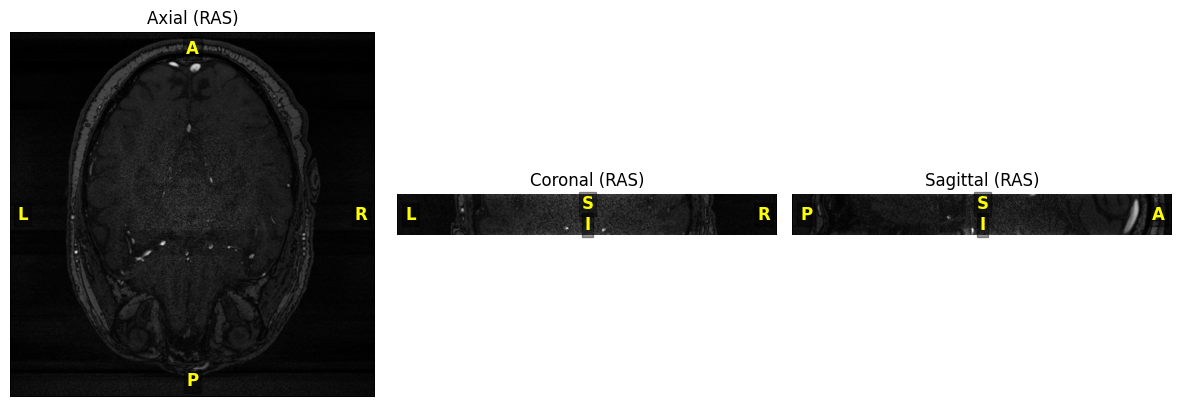

In [9]:
# Visualize NIfTI orientation (3D/4D) with direction labels
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
from nibabel.orientations import aff2axcodes, io_orientation
from nibabel.orientations import apply_orientation

# Path to the NIfTI file (adjust to your case)
nifti_path = "../data/nifti_patients/001_20240313_3T/Magnitude_NoProto_WIP_pc3d1r3.nii.gz"

img = nib.load(nifti_path)
data = img.get_fdata()
affine = img.affine

# Axis codes (L/R, A/P, S/I) in data order
axcodes = aff2axcodes(affine)
print("Current orientation (data):", axcodes)
print("Original shape:", data.shape)

# Reorient to RAS (Right-Anterior-Superior) for consistent viewing
# This does not change the file on disk; it only creates a reoriented view
ornt = io_orientation(affine)
ras_ornt = nib.orientations.axcodes2ornt(("R", "A", "S"))
transform = nib.orientations.ornt_transform(ornt, ras_ornt)
data_ras = apply_orientation(data, transform)

# If 4D, select a timepoint (or average) for visualization
if data_ras.ndim == 4:
    t = data_ras.shape[3] // 2  # middle timepoint
    vol = data_ras[:, :, :, t]
    print("Showing t =", t)
else:
    vol = data_ras

def add_labels(ax, left, right, top, bottom):
    ax.text(0.02, 0.5, left, transform=ax.transAxes, va="center", ha="left",
            color="yellow", fontsize=12, fontweight="bold", bbox=dict(facecolor="black", alpha=0.4, pad=2))
    ax.text(0.98, 0.5, right, transform=ax.transAxes, va="center", ha="right",
            color="yellow", fontsize=12, fontweight="bold", bbox=dict(facecolor="black", alpha=0.4, pad=2))
    ax.text(0.5, 0.98, top, transform=ax.transAxes, va="top", ha="center",
            color="yellow", fontsize=12, fontweight="bold", bbox=dict(facecolor="black", alpha=0.4, pad=2))
    ax.text(0.5, 0.02, bottom, transform=ax.transAxes, va="bottom", ha="center",
            color="yellow", fontsize=12, fontweight="bold", bbox=dict(facecolor="black", alpha=0.4, pad=2))

# Central slices for each plane
z = vol.shape[2] // 2
y = vol.shape[1] // 2
x = vol.shape[0] // 2

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# Axial: R/L (left-right), A/P (top-bottom) in RAS
axial = vol[:, :, z].T
axes[0].imshow(axial, cmap="gray", origin="lower")
axes[0].set_title("Axial (RAS)")
axes[0].axis("off")
add_labels(axes[0], left="L", right="R", top="A", bottom="P")

# Coronal: R/L (left-right), S/I (top-bottom) in RAS
coronal = vol[:, y, :].T
axes[1].imshow(coronal, cmap="gray", origin="lower")
axes[1].set_title("Coronal (RAS)")
axes[1].axis("off")
add_labels(axes[1], left="L", right="R", top="S", bottom="I")

# Sagittal: A/P (left-right), S/I (top-bottom) in RAS
sagittal = vol[x, :, :].T
axes[2].imshow(sagittal, cmap="gray", origin="lower")
axes[2].set_title("Sagittal (RAS)")
axes[2].axis("off")
add_labels(axes[2], left="P", right="A", top="S", bottom="I")

plt.tight_layout()
plt.show()

# In RAS: +X is Right, +Y is Anterior, +Z is Superior.

Current orientation (data): ('L', 'A', 'S')
Showing t = 4


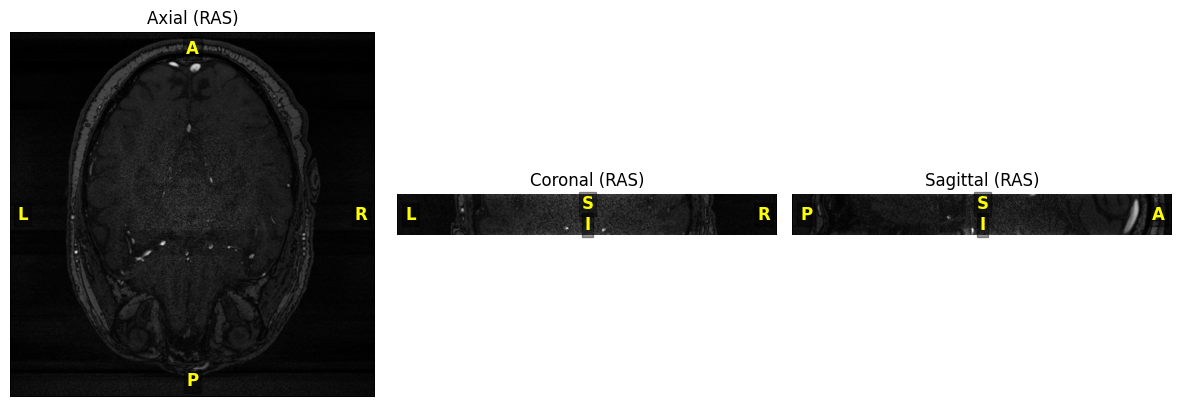

In [8]:
# Reorient LAS to RAS for visualization (with labels)
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
from nibabel.orientations import aff2axcodes, io_orientation
from nibabel.orientations import apply_orientation

# Path to the NIfTI file (adjust to your case)
nifti_path = "../data/nifti_patients/001_20240313_3T/Magnitude_NoProto_WIP_pc3d1r3.nii.gz"

img = nib.load(nifti_path)
data = img.get_fdata()
affine = img.affine

print("Current orientation (data):", aff2axcodes(affine))

# Force reorient to RAS for display
ornt = io_orientation(affine)
ras_ornt = nib.orientations.axcodes2ornt(("R", "A", "S"))
transform = nib.orientations.ornt_transform(ornt, ras_ornt)
data_ras = apply_orientation(data, transform)

# If 4D, pick a timepoint
if data_ras.ndim == 4:
    t = data_ras.shape[3] // 2
    vol = data_ras[:, :, :, t]
    print("Showing t =", t)
else:
    vol = data_ras

def add_labels(ax, left, right, top, bottom):
    ax.text(0.02, 0.5, left, transform=ax.transAxes, va="center", ha="left",
            color="yellow", fontsize=12, fontweight="bold", bbox=dict(facecolor="black", alpha=0.4, pad=2))
    ax.text(0.98, 0.5, right, transform=ax.transAxes, va="center", ha="right",
            color="yellow", fontsize=12, fontweight="bold", bbox=dict(facecolor="black", alpha=0.4, pad=2))
    ax.text(0.5, 0.98, top, transform=ax.transAxes, va="top", ha="center",
            color="yellow", fontsize=12, fontweight="bold", bbox=dict(facecolor="black", alpha=0.4, pad=2))
    ax.text(0.5, 0.02, bottom, transform=ax.transAxes, va="bottom", ha="center",
            color="yellow", fontsize=12, fontweight="bold", bbox=dict(facecolor="black", alpha=0.4, pad=2))

# Central slices
z = vol.shape[2] // 2
y = vol.shape[1] // 2
x = vol.shape[0] // 2

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axial = vol[:, :, z].T
axes[0].imshow(axial, cmap="gray", origin="lower")
axes[0].set_title("Axial (RAS)")
axes[0].axis("off")
add_labels(axes[0], left="L", right="R", top="A", bottom="P")

coronal = vol[:, y, :].T
axes[1].imshow(coronal, cmap="gray", origin="lower")
axes[1].set_title("Coronal (RAS)")
axes[1].axis("off")
add_labels(axes[1], left="L", right="R", top="S", bottom="I")

sagittal = vol[x, :, :].T
axes[2].imshow(sagittal, cmap="gray", origin="lower")
axes[2].set_title("Sagittal (RAS)")
axes[2].axis("off")
add_labels(axes[2], left="P", right="A", top="S", bottom="I")

plt.tight_layout()
plt.show()

# Note: aff2axcodes prints header orientation (still LAS),
# but the displayed views are reoriented to RAS.